In [1]:
import sys
from pathlib import Path

import numpy as np
import netCDF4 as nc
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from configs import paths

## Configuration

In [10]:
# Which split to load (0–8)
SPLIT_IDX = 1

# Which partition to plot: 'tr', 'va', or 'te'
PARTITION = 'tr'

# Which sample index within that partition to plot
SAMPLE_IDX = 0

## Load grid and split file

In [3]:
# ------------------------------------------------------------------
# Grid  (lat / lon on the CESM2 POP ocean grid)
# ------------------------------------------------------------------
grid_path = paths.CESM2LE_SST_DIR / 'grid' / 'cesm2le_sst_grid.nc'

with nc.Dataset(str(grid_path), 'r') as ds_grid:
    lat = np.array(ds_grid.variables['lat'][:],  dtype=np.float32)   # (nx, ny)
    lon = np.array(ds_grid.variables['lon'][:], dtype=np.float32)   # (nx, ny)

print(f'Grid shape : {lat.shape}')

Grid shape : (192, 288)


In [11]:
# ------------------------------------------------------------------
# TVT split file
# ------------------------------------------------------------------
split_path = paths.tvt_split_path(SPLIT_IDX)
print(f'Loading : {split_path}')

ds = xr.open_dataset(split_path)
print(ds)

mu    = float(ds['mu_train'])
sigma = float(ds['sigma_train'])
print(f'\nmu_train    = {mu:.4f} °C')
print(f'sigma_train = {sigma:.4f} °C')

Loading : /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/arcticWatch/results/tvt_splits/cesm2le_sst_jja_slowdown_split1.nc
<xarray.Dataset> Size: 1GB
Dimensions:      (ntr: 4080, nx: 192, ny: 288, nva: 510, nte: 510)
Coordinates:
  * ntr          (ntr) int64 33kB 0 1 2 3 4 5 ... 4074 4075 4076 4077 4078 4079
  * nva          (nva) int64 4kB 0 1 2 3 4 5 6 7 ... 503 504 505 506 507 508 509
  * nte          (nte) int64 4kB 0 1 2 3 4 5 6 7 ... 503 504 505 506 507 508 509
  * nx           (nx) int64 2kB 0 1 2 3 4 5 6 7 ... 185 186 187 188 189 190 191
  * ny           (ny) int64 2kB 0 1 2 3 4 5 6 7 ... 281 282 283 284 285 286 287
Data variables:
    sst_tr       (ntr, nx, ny) float32 902MB ...
    sst_va       (nva, nx, ny) float32 113MB ...
    sst_te       (nte, nx, ny) float32 113MB ...
    slow_tr      (ntr) int8 4kB ...
    slow_va      (nva) int8 510B ...
    slow_te      (nte) int8 510B ...
    mu_train     float32 4B ...
    sigma_train  float32 4B ...
Attributes:
    split_idx: 

In [5]:
# ------------------------------------------------------------------
# Partition summary
# ------------------------------------------------------------------
for part, label_key, sst_key in [
        ('train', 'slow_tr', 'sst_tr'),
        ('val',   'slow_va', 'sst_va'),
        ('test',  'slow_te', 'sst_te')]:
    labels = ds[label_key].values
    n_slow = labels.sum()
    print(f'  {part:5s}  n={len(labels):5d}   slowdown={n_slow:4d} ({100*n_slow/len(labels):.1f}%)')

  train  n= 4080   slowdown=1123 (27.5%)
  val    n=  510   slowdown= 158 (31.0%)
  test   n=  510   slowdown= 136 (26.7%)


## Map of one SST sample

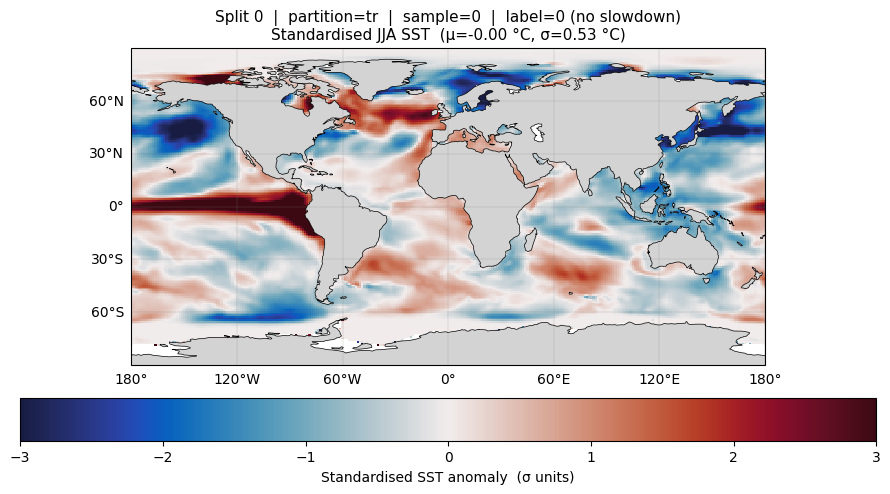

In [6]:
# ------------------------------------------------------------------
# Plot standardised SST (land sentinel = -10 masked out)
# ------------------------------------------------------------------
sst_key = f'sst_{PARTITION}'
sst_std = ds[sst_key].values[SAMPLE_IDX]          # (nx, ny)

label_key = f'slow_{PARTITION}'
label = int(ds[label_key].values[SAMPLE_IDX])
label_str = 'slowdown' if label == 1 else 'no slowdown'

# Mask land sentinel
sst_plot = np.ma.masked_where(sst_std <= -9, sst_std)

fig = plt.figure(figsize=(11, 5))
ax  = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.coastlines(linewidth=0.5, color='k', zorder=3)

im = ax.pcolormesh(
    lon, lat, sst_plot,
    vmin=-3, vmax=3,
    cmap=cmocean.cm.balance,
    shading='auto',
    transform=ccrs.PlateCarree(),
)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
gl.top_labels   = False
gl.right_labels = False

ax.set_title(
    f'Split {SPLIT_IDX}  |  partition={PARTITION}  |  sample={SAMPLE_IDX}  |  label={label} ({label_str})\n'
    f'Standardised JJA SST  (μ={mu:.2f} °C, σ={sigma:.2f} °C)',
    fontsize=11, pad=6,
)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.08, shrink=0.8)
cbar.set_label('Standardised SST anomaly  (σ units)', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Same sample back in physical units  (°C anomaly from ensemble mean)
# ------------------------------------------------------------------
sst_phys = np.ma.masked_where(sst_std <= -9, sst_std * sigma + mu)

fig = plt.figure(figsize=(11, 5))
ax  = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.coastlines(linewidth=0.5, color='k', zorder=3)

im = ax.pcolormesh(
    lon, lat, sst_phys,
    vmin=-5, vmax=5,
    cmap=cmocean.cm.balance,
    shading='auto',
    transform=ccrs.PlateCarree(),
)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
gl.top_labels   = False
gl.right_labels = False

ax.set_title(
    f'Split {SPLIT_IDX}  |  partition={PARTITION}  |  sample={SAMPLE_IDX}  |  label={label} ({label_str})\n'
    f'JJA SST anomaly (physical units, °C)',
    fontsize=11, pad=6,
)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.08, shrink=0.8)
cbar.set_label('JJA SST anomaly  (°C)', fontsize=10)

plt.tight_layout()
plt.show()

## Composite mean & std of standardised SST by class (slowdown = 1 vs 0)

N(slowdown=1) =  1417
N(slowdown=0) =  3683


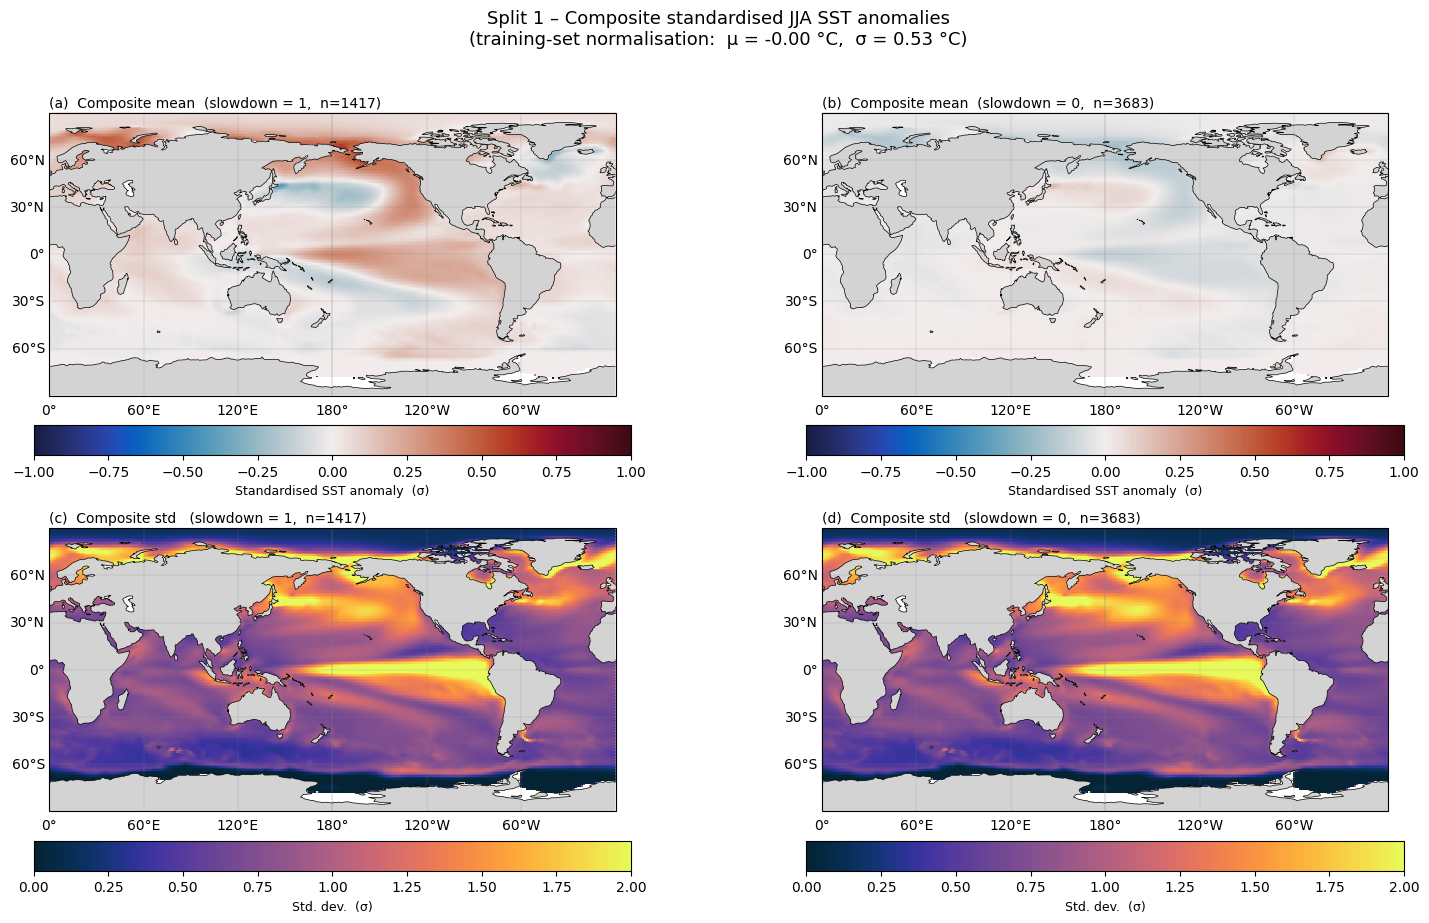

In [12]:
# ------------------------------------------------------------------
# Composite mean & std of standardised SST  (slowdown=1 vs slowdown=0)
# Pooled across all three partitions for maximum sample size
# ------------------------------------------------------------------
LAND_SENTINEL = -9.0

# Pool SST arrays and labels from all partitions
all_sst = np.ma.masked_where(
    np.concatenate([ds['sst_tr'].values,
                    ds['sst_va'].values,
                    ds['sst_te'].values], axis=0) <= LAND_SENTINEL,
    np.concatenate([ds['sst_tr'].values,
                    ds['sst_va'].values,
                    ds['sst_te'].values], axis=0),
)  # (N_total, nx, ny), standardised anomalies

all_labels = np.concatenate([
    ds['slow_tr'].values,
    ds['slow_va'].values,
    ds['slow_te'].values,
], axis=0)  # (N_total,)

# Split by class
idx_slow   = all_labels == 1
idx_noslow = all_labels == 0

sst_slow   = all_sst[idx_slow]    # (N1, nx, ny)
sst_noslow = all_sst[idx_noslow]  # (N0, nx, ny)

print(f'N(slowdown=1) = {idx_slow.sum():5d}')
print(f'N(slowdown=0) = {idx_noslow.sum():5d}')

# Composite statistics
mean_slow   = sst_slow.mean(axis=0)
mean_noslow = sst_noslow.mean(axis=0)
std_slow    = sst_slow.std(axis=0, ddof=1)
std_noslow  = sst_noslow.std(axis=0, ddof=1)

# ------------------------------------------------------------------
# 4-panel figure
# (a) composite mean  | slowdown=1
# (b) composite mean  | slowdown=0
# (c) composite std   | slowdown=1
# (d) composite std   | slowdown=0
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    2, 2, figsize=(16, 9),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
)

panels = [
    (axes[0, 0], mean_slow,   'a',
     f'Composite mean  (slowdown = 1,  n={idx_slow.sum()})',
     cmocean.cm.balance, -1.0,  1.0, 'Standardised SST anomaly  (σ)'),
    (axes[0, 1], mean_noslow, 'b',
     f'Composite mean  (slowdown = 0,  n={idx_noslow.sum()})',
     cmocean.cm.balance, -1.0,  1.0, 'Standardised SST anomaly  (σ)'),
    (axes[1, 0], std_slow,    'c',
     f'Composite std   (slowdown = 1,  n={idx_slow.sum()})',
     cmocean.cm.thermal,  0.0,  2.0, 'Std. dev.  (σ)'),
    (axes[1, 1], std_noslow,  'd',
     f'Composite std   (slowdown = 0,  n={idx_noslow.sum()})',
     cmocean.cm.thermal,  0.0,  2.0, 'Std. dev.  (σ)'),
]

for ax, data, label, title, cmap, vmin, vmax, cbar_label in panels:
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
    ax.coastlines(linewidth=0.5, color='k', zorder=3)

    im = ax.pcolormesh(
        lon, lat, data,
        vmin=vmin, vmax=vmax,
        cmap=cmap,
        shading='auto',
        transform=ccrs.PlateCarree(),
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
    gl.top_labels   = False
    gl.right_labels = False

    ax.set_title(f'({label})  {title}', fontsize=10, loc='left', pad=4)

    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.08, shrink=0.75)
    cbar.set_label(cbar_label, fontsize=9)

fig.suptitle(
    f'Split {SPLIT_IDX} – Composite standardised JJA SST anomalies\n'
    f'(training-set normalisation:  μ = {mu:.2f} °C,  σ = {sigma:.2f} °C)',
    fontsize=13, y=1.02,
)

plt.tight_layout()
plt.show()